# Exploratory Data Analysis

## About the data

Description of the German credit dataset:
Source:
- Professor Dr. Hans Hofmann
- Institut f"ur Statistik und "Okonometrie
- Universit"at Hamburg
- FB Wirtschaftswissenschaften
- Von-Melle-Park 5
- 2000 Hamburg 13

Number of instances: 1000

Number of categorical/symbolic attributes: 20 (13/7)

Each entry represents a person who takes a credit by a bank (data)

Each person is classified as a good or bad credit risks according to the set of attributes (target)

## Import and inspect the data

Import the data into the evaluation environment

It's critical to look into the statistics, so you can gain initial know-how of its structure, variable kinds, and potential issues

Here are a few tasks:
- Load the data, ensuring it is imported efficiently and without errors
- Examine the size of the data (number of rows and columns) to assess its size
- Identify data types and formats
- Look for any apparent errors or inconsistencies in the information, such as invalid values, mismatched units, or outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

In [2]:
import os

DATA_PATH = '../data/raw/credit_g.csv'

if not os.path.exists(DATA_PATH):
    raw = fetch_openml('credit-g', version=1, as_frame=True)
    os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
    raw.frame.to_csv(DATA_PATH, index=False)

df = pd.read_csv(DATA_PATH, dtype={'class': 'category'})
df = df.rename(columns={'class': 'target'})


We download from OpenML, or load it if we already downloaded it

Let's take a first look at the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   object  
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   object  
 3   purpose                 1000 non-null   object  
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   object  
 6   employment              1000 non-null   object  
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   object  
 9   other_parties           1000 non-null   object  
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   object  
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   object  
 14  housing                 1

In [4]:
df.shape # 20 features, the 1 last one is the target variable 

(1000, 21)

In [5]:
df.describe(include='all').T.sort_values('unique', ascending=False)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
purpose,1000,10,radio/tv,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_history,1000,5,existing paid,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
savings_status,1000,5,<100,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment,1000,5,1<=X<4,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
checking_status,1000,4,no checking,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
personal_status,1000,4,male single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_magnitude,1000,4,car,332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job,1000,4,skilled,630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_parties,1000,3,none,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_payment_plans,1000,3,none,814,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Some questions

What we want to know?

We want to answer some questions, like:
- Which features determine if a person will be a good or bad payer?
- In which case should we assume someone will be a bad payer?

What info do we have?

We have personal info, such as the gender, age, social status, residence, etc. Also about their jobs and finance status, like savings, credit history, job, etc. And some about the credit they are asking, like purpose and amount.

How many info do we have?

We have a complete dataset with: 1000 rows, and each one corresponds to a person. Each row has 20 variables (some nominal, some numeral) and a label (if they are good or bad payer)

Is there something important" we should know?

Yes, a bad payer costs the bank around 5 times more than good payers

## Data quality

We search for missing values, duplicates, outliers for each variable

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

No missing values nor duplicated, let's seek outliers

<Axes: xlabel='target'>

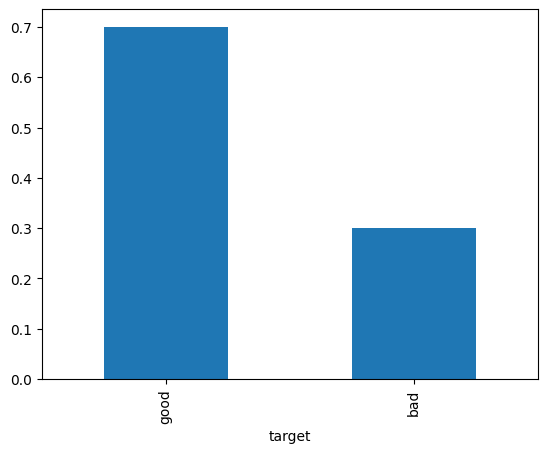

In [8]:
# Class imbalance: 700 good vs 300 bad
df['target'].value_counts(normalize=True).plot(kind='bar')

There is an imbalance between the target classes. 70% good / 30% bad

We will need to consider class_weight or resampling later when modeling

In [9]:
num_cols = df.select_dtypes(['float64', 'int64']).columns

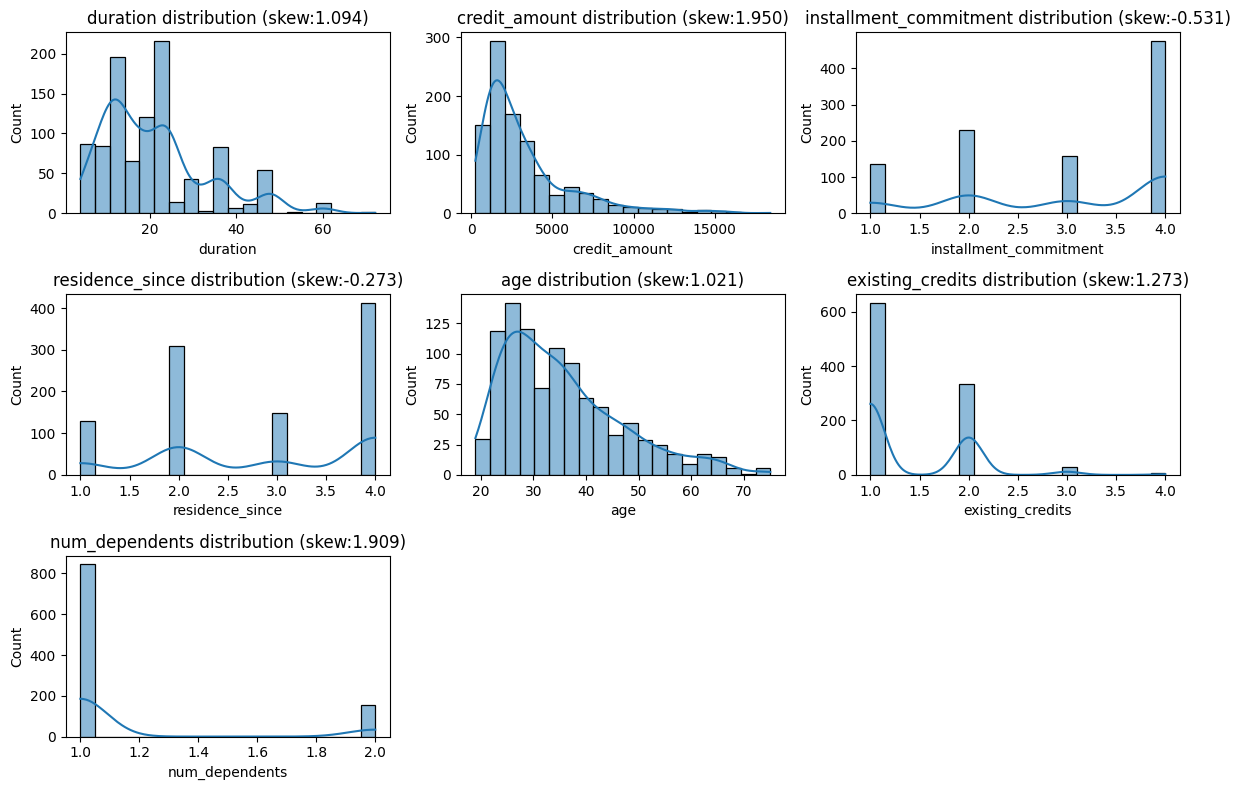

In [10]:
plt.figure(figsize=(12,8))

for i, feature in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[feature], bins=20, kde=True)
    plt.title(f'{feature} distribution (skew:{df[feature].skew():.3f})')
plt.tight_layout()
plt.show()

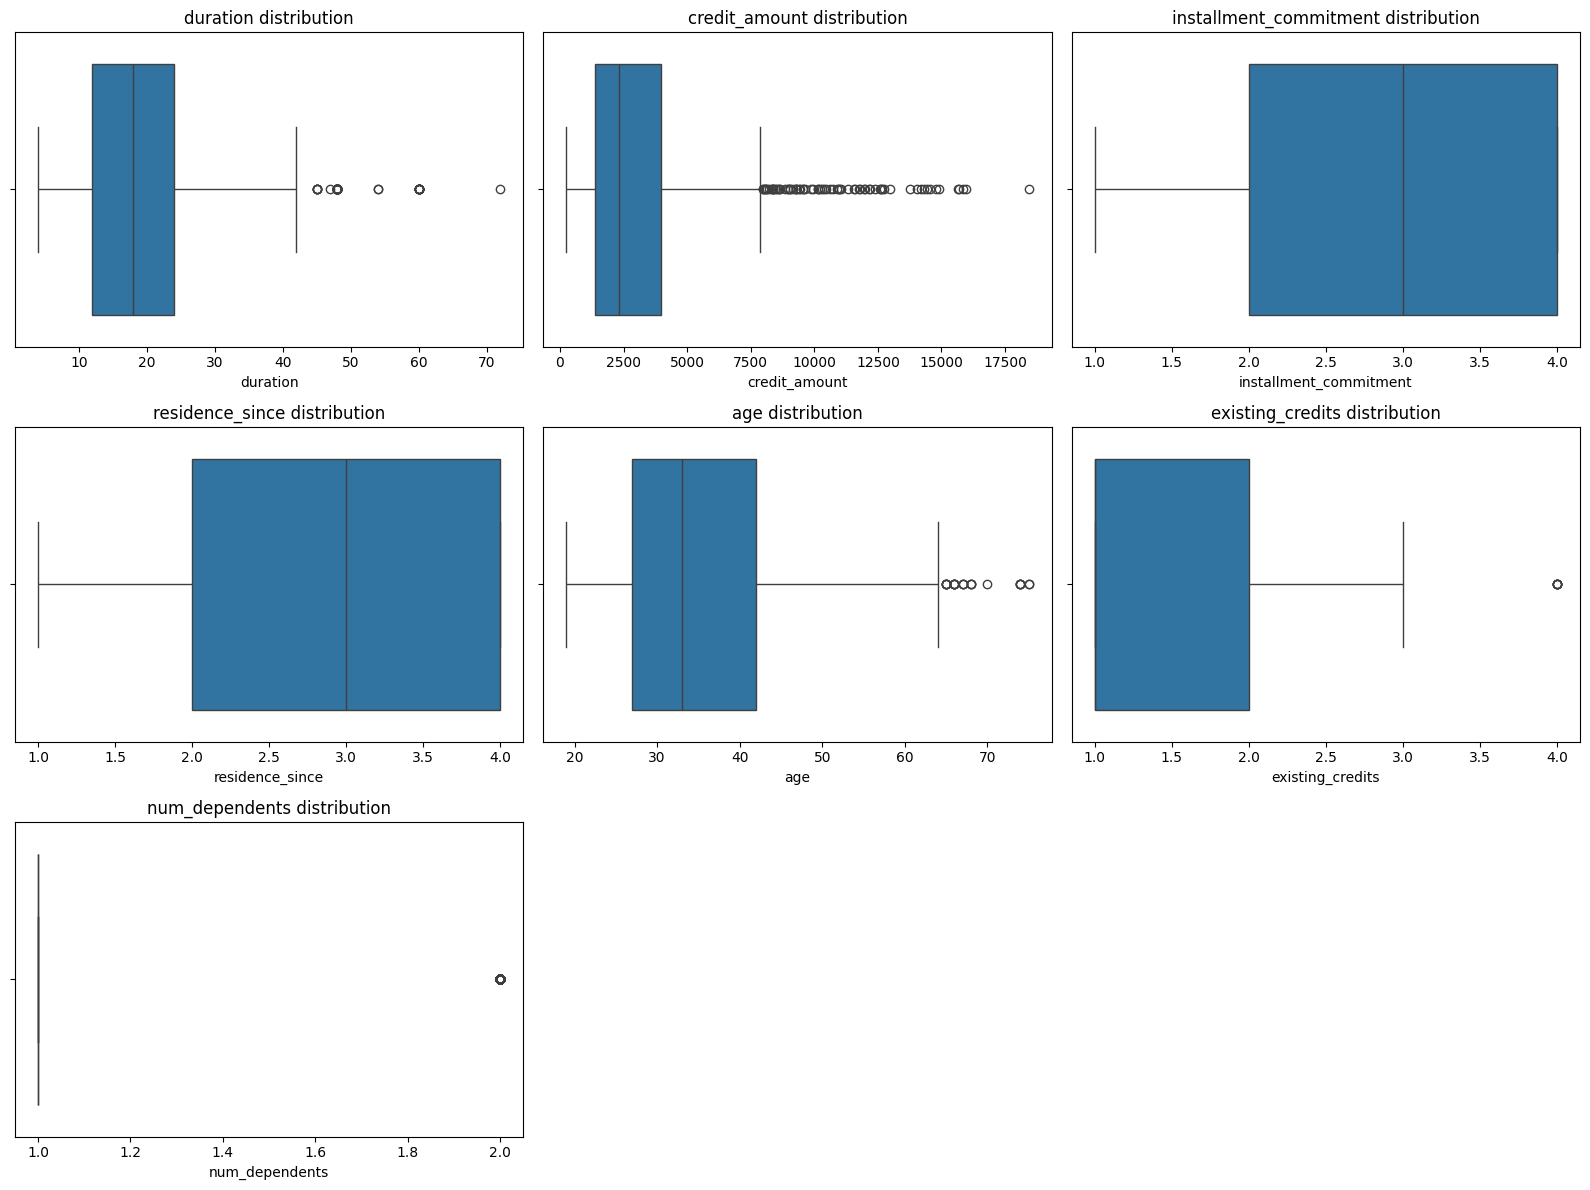

In [11]:
plt.figure(figsize=(16,12))

for i, feature in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[feature])
    plt.title(f'{feature} distribution')
plt.tight_layout()
plt.show()

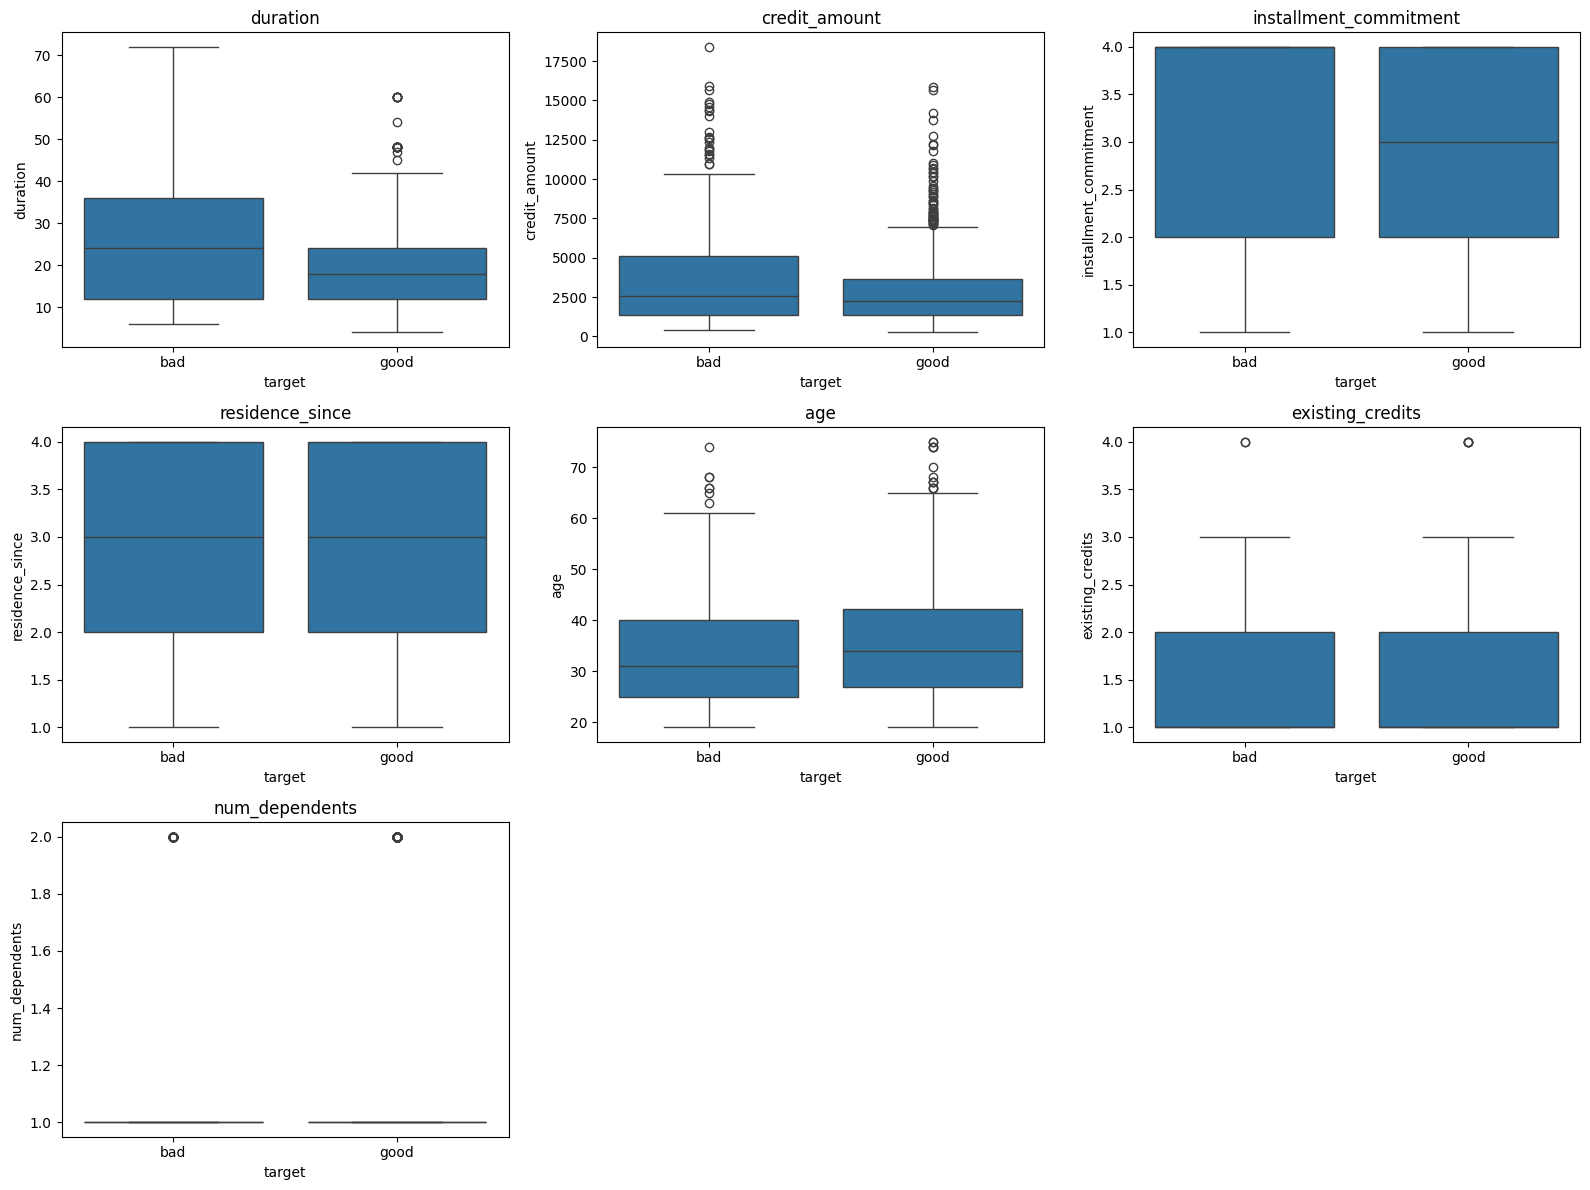

In [12]:
plt.figure(figsize=(16,12))

for i, feature in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df['target'], y=df[feature])
    plt.title(f'{feature}')
plt.tight_layout()
plt.show()

We can see that bad payers' credits tend to have larger durations

In [13]:
# Para cada variable categórica: frecuencia + tasa de bad payers por categoría
cat_cols = df.select_dtypes('category').drop('target', axis=1).columns

In [14]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.countplot(x=df[col], ax=axes[0])
    sns.barplot(x=df[col], y=(df['target'] == 'bad').astype(int), ax=axes[1], color='red')
    
    axes[0].set_title(f'{col} distribution')
    axes[1].set_title(f'{col} vs target (bad payer rate)')

    axes[0].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [15]:
df['credit_amount'].describe()

,credit_amount
count,1000.000000
mean,3271.258000
std,2822.736876
min,250.000000
25%,1365.500000
50%,2319.500000
75%,3972.250000
max,18424.000000


With this info and the graphics, we notice that `credit_amount` is skewed, and the majority of credits are between $1300 and $4000

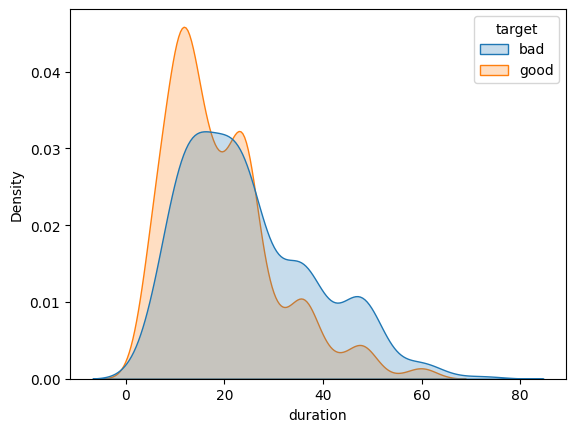

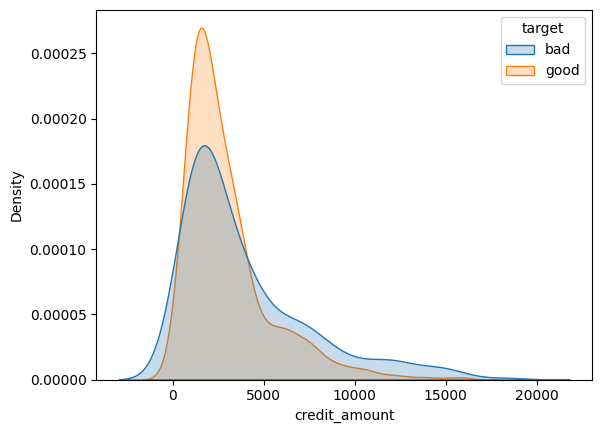

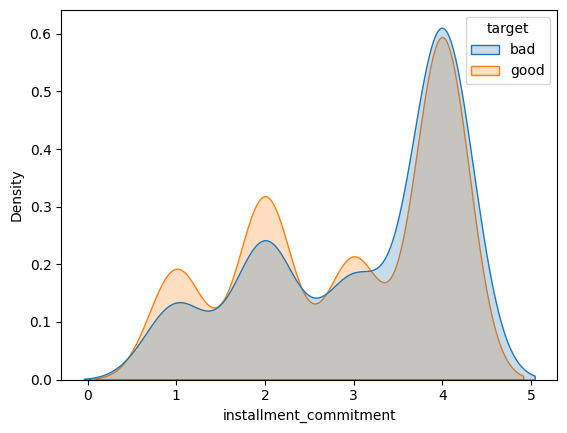

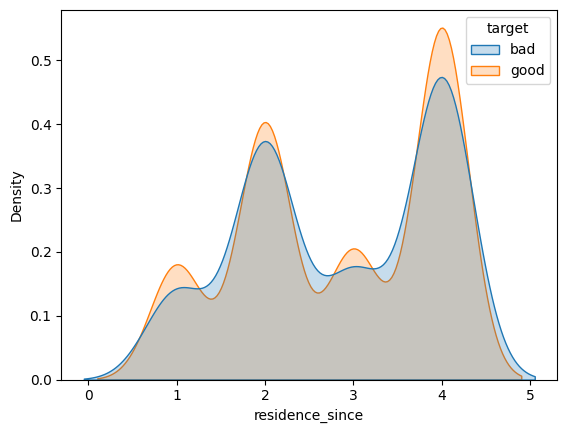

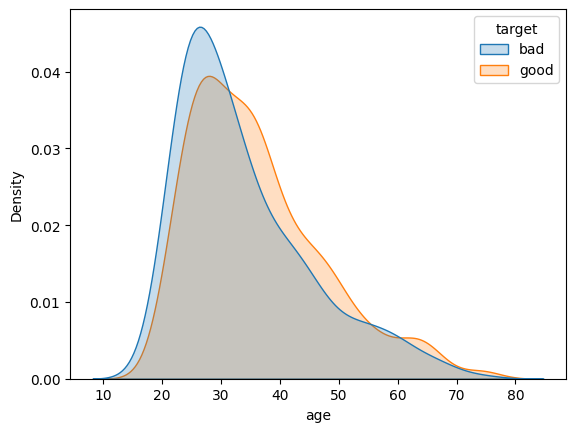

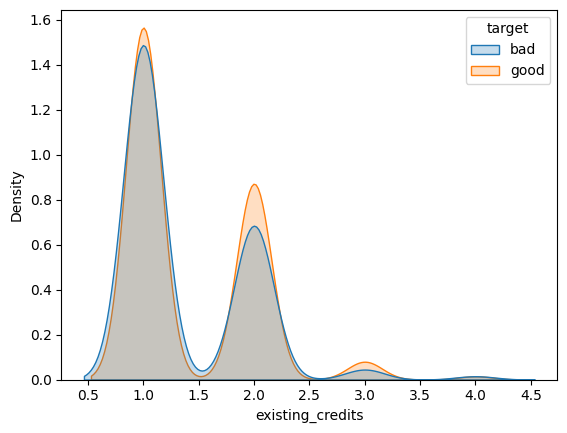

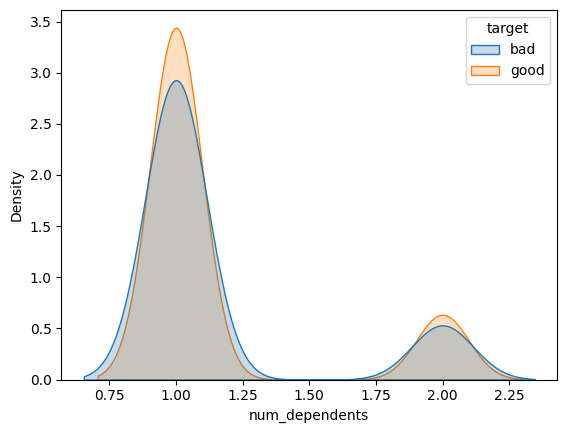

In [16]:
for col in num_cols:
    sns.kdeplot(data=df, x=col, hue='target', fill=True, common_norm=False)
    # common_norm=False normalizes the distribution of each class separately, so that the area under the curve for each class sums to 1
    # This allows us to compare the shapes of the distributions without being affected by class imbalance
    plt.show()

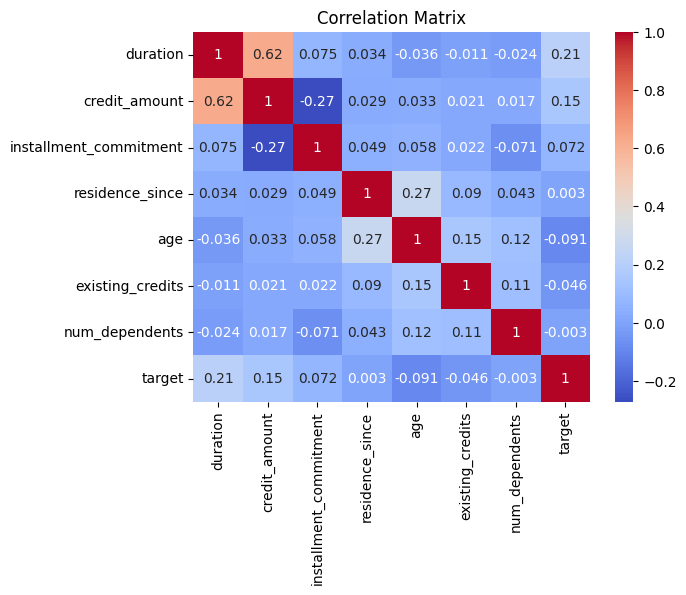

In [17]:
corr_df = df.select_dtypes(['int64', 'float64']).copy()
corr_df['target'] = (df['target'] == 'bad').astype('int64')

sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The correlation matrix helps us to identify which features are more correlated with the target variable, and also to identify multicollinearity between features.

In this case, we can see that 'duration' and 'credit_amount' are the most correlated with the target variable.

We can also see that there is a high correlation between 'duration' and 'credit_amount', which could indicate multicollinearity.

## Conclusions

- The target class is imbalanced, there are 70% good / 30% bad.
- The more discriminant features are indeed `credit_amount` and `duration`, in relation to `target`. Their correlation is 0.15 and 0.21 respectively.
- Also there may be multicollinearity between them, with a correlation about 0.67. This make sense, as higher credit amounts are likely to be associated with longer durations.
- `credit_amount`: Most of the credits are between 1365 (Q1) and 3972 (Q3), but the max is 18424, there are important outliers. The distribution is not symmetric and has a long tail to the right side (higher amounts), so it has a high skewness (consider log transformation). The boxplots we made may indicate that there are some bad payers who have taken out very large loans, which could be a risk factor for default.
- `checking_status`: People listed as 'no checking' have a lower default rate
- `credit_history`: Those listed as 'critical/other' have a higher default rate (paradoxical; worth investigating)
- `purpose`: 'vacation/others' and 'retraining' have a high default rate

## Next steps

Data doesn't have missing values nor duplicated, that's good.

Preprocess skewd features like `credit_amount`, so we dont have problem with linear models.

Encode categorical variables.